Importing necessary libraries

In [35]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

Loading the data

In [36]:
df=pd.read_csv('/content/Titanic.csv')

In [37]:
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


In [39]:
df.isnull().sum()

,0
Unnamed: 0,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0


In [40]:
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipykernel_29826/1654433547.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [41]:
#df.drop(['Cabin','Ticket','Name'], axis=1, inplace=True)

In [42]:
df['sex'] = df['sex'].map({'male':0 ,'female':1})

In [43]:
X = df[['pclass','sex','age','sibsp','parch','fare']]
Y = df['survived']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [45]:
model = RandomForestClassifier()

In [46]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [47]:
a = accuracy_score(y_test, model.predict(X_test))
print("Accuracy:",f"{a:.2%}")

Accuracy: 79.89%


Visualization

/tmp/ipykernel_29826/979087323.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Survived', 'Died'])


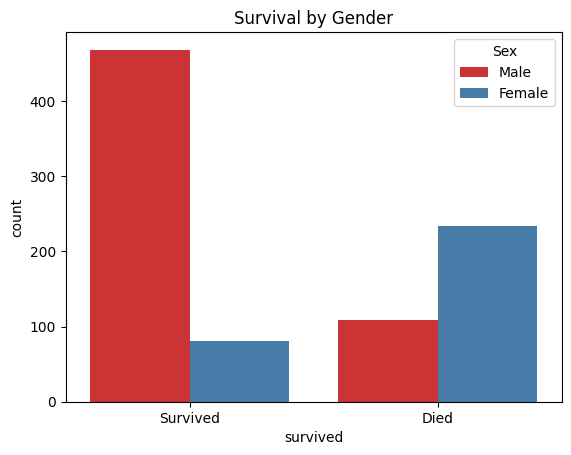

In [48]:
ax = sns.countplot(x='survived', hue='sex', data=df, palette='Set1')
ax.set_xticklabels(['Survived', 'Died'])
handles,labels=ax.get_legend_handles_labels()
ax.legend(handles,['Male','Female'], title='Sex')
plt.title('Survival by Gender')
plt.show()